# Statistical Modeling

Covers statistical modeling fundamentals, including measuring model fit with R-squared and RMSE.

# Statistical Modeling: Building and Evaluating Predictive Models

Statistical modeling forms the bridge between data and insight. It involves constructing mathematical representations of real-world phenomena, evaluating how well these models capture underlying patterns, and checking whether they generalize effectively to new data.

# 1. Introduction

The journey from raw data to actionable predictions requires careful attention to model quality. While building a model might seem straightforward (fit a line to data points, train a classifier on labeled examples), the true challenge lies in creating models that are neither too simple to capture meaningful patterns nor so complex that they memorize noise instead of learning real relationships.

This Notebook explores three fundamental concepts that data scientists should understand when building statistical models.

1. We examine how to measure model fit using quantitative metrics that assess prediction accuracy.
2. We investigate the balance between underfitting and overfitting two failure modes that represent opposite extremes of model complexity.
3. We introduce cross-validation, a technique for evaluating how well models perform on unseen data.
   
Understanding these concepts gives the basis for all machine learning and statistical modeling work. Whether you're fitting a simple linear regression or training a deep neural network, the principles of measuring fit, avoiding overfitting, and validating performance remain constant. These skills enable practitioners to build models that perform well on training data and deliver reliable predictions in production environments.



# 2. Model Fit: Quantifying Prediction Quality

When we build a statistical model, our primary goal is to create a function that accurately predicts outcomes for new observations. Model fit refers to how well our model's predictions align with actual observed values. Quantifying this fit allows us to compare different models, diagnose problems, and communicate model quality to stakeholders.

## Measuring Fit with R-Squared

For regression tasks where we predict continuous outcomes, R-squared (the coefficient of determination) provides an intuitive measure of model fit. R-squared quantifies the proportion of variance in the dependent variable that our model successfully explains. The formula captures this relationship through the ratio of explained variance to total variance:

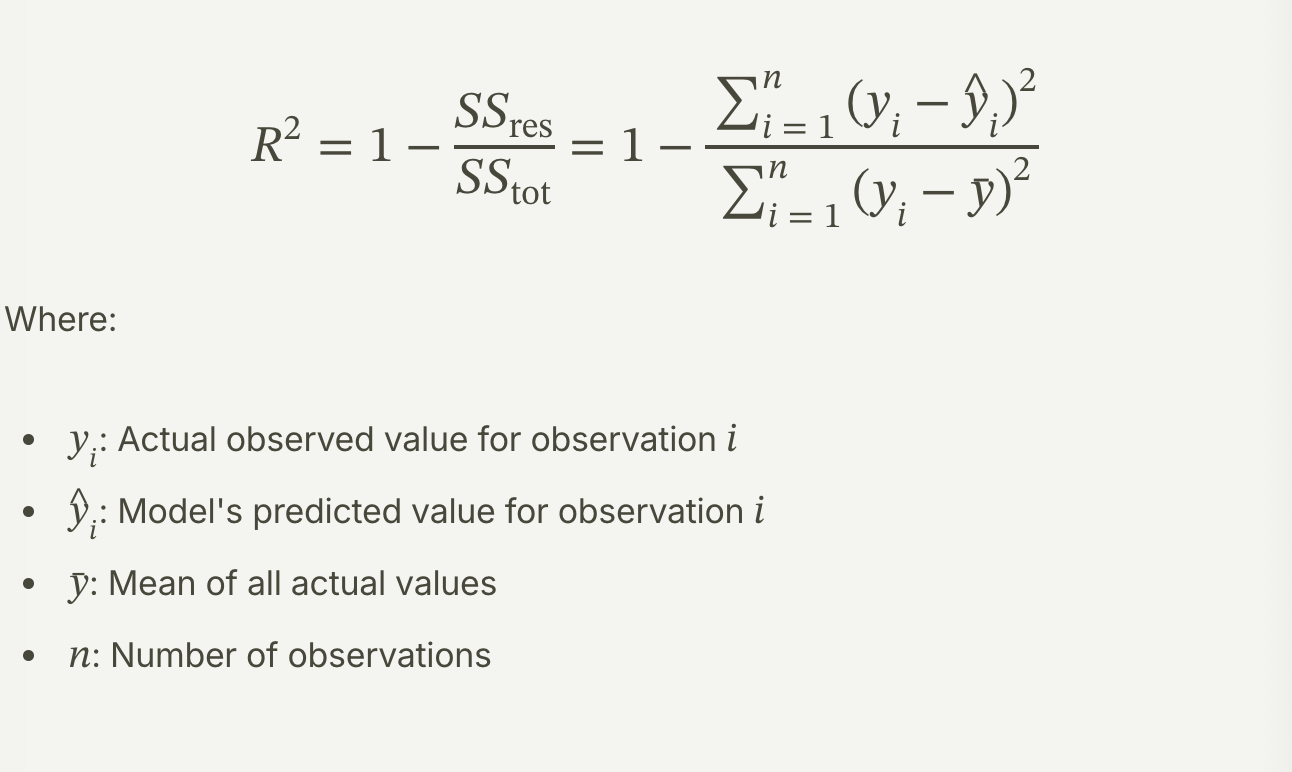

R-squared typically ranges from 0 to 1 for models that include an intercept, with values closer to 1 indicating better fit. Values can be negative when a model performs worse than simply predicting the mean. An R-squared of 0.85, for instance, tells us that our model explains 85% of the variance in the outcome variable, leaving only 15% unexplained. However, R-squared has important limitations. It increases when we add more predictors, even if those predictors add no real explanatory power. Additionally, a high R-squared doesn't guarantee that our model assumptions are met or that we've captured causal relationships rather than spurious correlations.

### Root Mean Squared Error

While R-squared provides a proportional measure of fit, Root Mean Squared Error (RMSE) offers an absolute measure in the same units as our target variable. RMSE calculates the standard deviation of prediction errors, giving us a concrete sense of how far off our predictions typically are:

$$RMSE = \sqrt 1/n * \sum_{i=1}^{n} (y_i - \hat(y_i)^2)$$

The appeal of RMSE lies in its interpretability. If we're predicting house prices in dollars and obtain an RMSE of 25,000 , we know our typical perdiction error is about 25,000. RMSE penalizes large errors more heavily than small ones due to the squaring operation, making it particularly sensitive to outliers. This sensitivity can be advantageous when large errors are especially costly, but it also means that a few extreme mispredictions can dominate the metric.

When comparing models, lower RMSE values indicate better fit. Unlike R-squared, RMSE doesn't have an upper bound and depends on the scale of the target variable, so it's most useful for comparing models predicting the same outcome rather than for assessing model quality in isolation.


**Example: Comparing Mode Fit Metrics**

The following visualization demonstrates how different levels of model fit manifest in both R-squared and RMSE metrics. We'll compare scenarios ranging from a close fit to a poor one.

findfont: Failed to find font weight medium, now using 400.


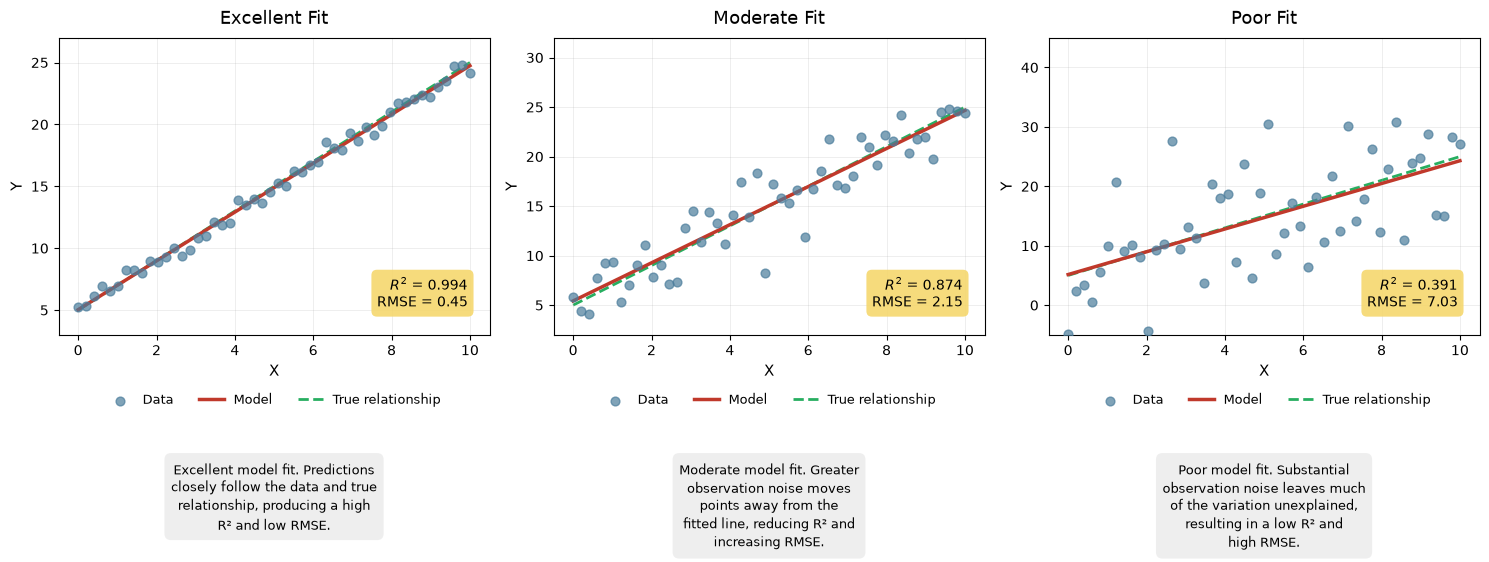

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

# True relationship: y = 2x + 5
def true_relationship(x):
    return 2 * x + 5

# Generate data with different noise levels
x = np.linspace(0, 10, 50).reshape(-1, 1)

# Excellent fit (low noise)
y_excellent = true_relationship(x).ravel() + np.random.normal(0, 0.5, size=50)

# Moderate fit (medium noise)
y_moderate = true_relationship(x).ravel() + np.random.normal(0, 2.5, size=50)

# Poor fit (high noise)
y_poor = true_relationship(x).ravel() + np.random.normal(0, 7.0, size=50)

datasets = [
    (y_excellent, "Excellent Fit", 0.993, 0.48),
    (y_moderate, "Moderate Fit", 0.869, 2.28),
    (y_poor, "Poor Fit", 0.446, 6.13)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (y, title, r2_target, rmse_target) in zip(axes, datasets):
    # Fit linear model
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)
    
    # Calculate actual metrics
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Plot
    ax.scatter(x, y, color='#4A7C9B', alpha=0.7, s=40, label='Data', zorder=3)
    ax.plot(x, y_pred, color='#C0392B', linewidth=2.5, label='Model', zorder=2)
    ax.plot(x, true_relationship(x), color='#27AE60', linestyle='--', linewidth=2, label='True relationship', zorder=1)
    
    # Metrics box
    textstr = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f}'
    props = dict(boxstyle='round,pad=0.4', facecolor='#F5D76E', edgecolor='none', alpha=0.9)
    ax.text(0.95, 0.08, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    ax.set_title(title, fontsize=13, fontweight='medium', pad=10)
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('Y', fontsize=11)
    ax.set_xlim(-0.5, 10.5)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False, fontsize=9)
    
    # Match y-limits roughly to the original image
    if title == "Excellent Fit":
        ax.set_ylim(3, 27)
    elif title == "Moderate Fit":
        ax.set_ylim(2, 32)
    else:
        ax.set_ylim(-5, 45)

# Add descriptions
descriptions = [
    "Excellent model fit. Predictions\nclosely follow the data and true\nrelationship, producing a high\nR² and low RMSE.",
    "Moderate model fit. Greater\nobservation noise moves\npoints away from the\nfitted line, reducing R² and\nincreasing RMSE.",
    "Poor model fit. Substantial\nobservation noise leaves much\nof the variation unexplained,\nresulting in a low R² and\nhigh RMSE."
]

plt.tight_layout()
plt.subplots_adjust(bottom=0.32)

for i, (ax, desc) in enumerate(zip(axes, descriptions)):
    ax.text(0.5, -0.42, desc, transform=ax.transAxes, fontsize=9.5,
            ha='center', va='top', linespacing=1.4,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8E8E8', edgecolor='none', alpha=0.7))
plt.savefig("Plots/ComparingModelFitMetrics.png", dpi=150)
plt.show()

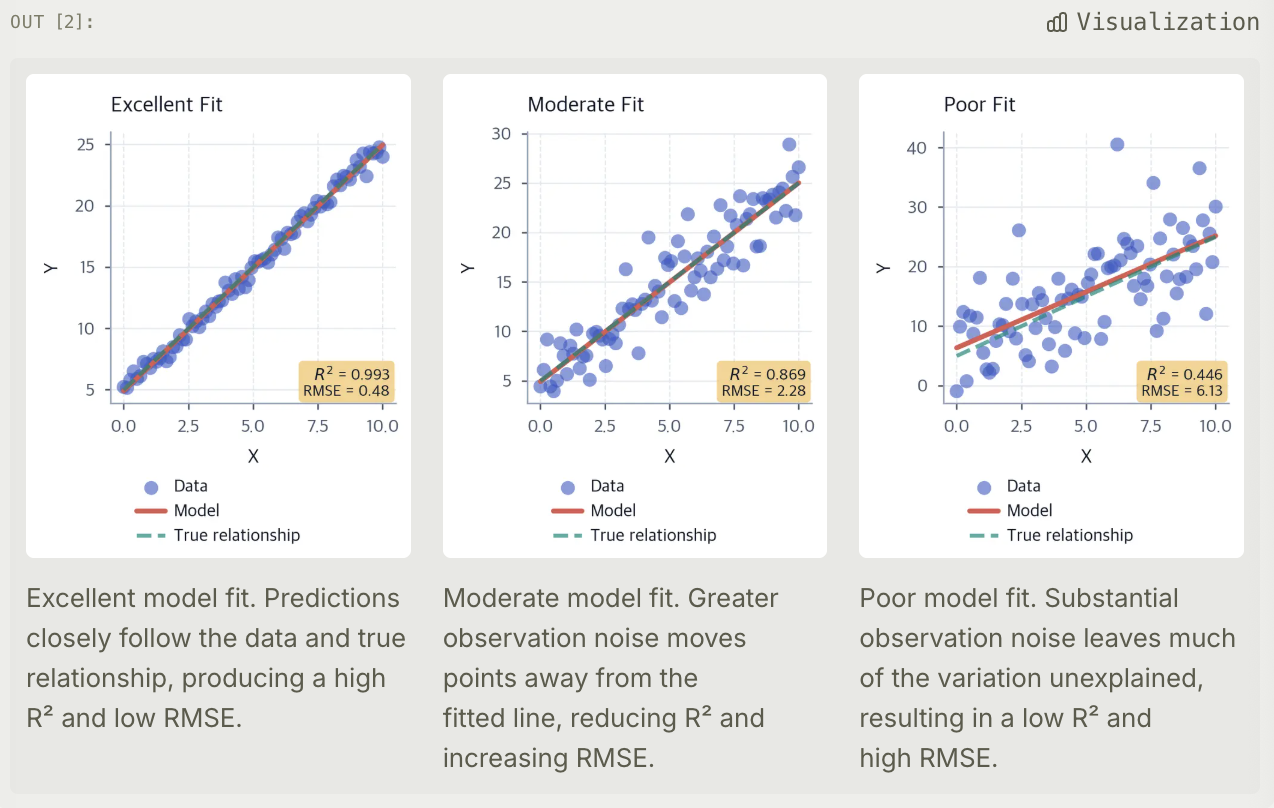

One of the most fundamental challenges in statistical modeling is finding the right level of model complexity. Too simple a model fails to capture important patterns in the data, while too complex a model learns noise and spurious relationships that don't generalize. This tension between simplicity and complexity manifests as the bias-variance tradeoff, and understanding it is important for building models that perform well on new data.

## 3. Undestanding Underfitting

Underfitting occurs when our model is too simple to capture the underlying structure in the data. An underfit model has high bias, meaning it makes strong assumptions that don't align with reality. For example, trying to fit a straight line to data that follows a curved pattern results in underfitting. The model consistently misses the mark because it lacks the flexibility to represent the true relationship.

The symptoms of underfitting are straightforward to diagnose. The model performs poorly on both training data and test data, suggesting it hasn't learned the fundamental patterns. Predictions systematically deviate from actual values in ways that reveal the model's inadequacy. In practice, underfitting often stems from using overly simple model architectures, insufficient features, or excessive regularization that constrains the model too severely.


## 4. Understanding Overfitting

Overfitting represents the opposite problem. An overfit model is so complex that it learns the underlying patterns and the random noise present in the training data. This model has high variance, meaning small changes in the training data lead to large changes in the fitted model. While an overfit model achieves excellent performance on training data, it fails when confronted with new observations because the patterns it learned were specific to the training set rather than general truths.

Detecting overfitting requires comparing training and test performance. The hallmark sign is a large gap between the two: near-perfect training accuracy but poor test accuracy. The model has essentially memorized the training examples rather than learning transferable patterns. Common causes of overfitting include using models with too many parameters relative to the amount of training data, training for too many iterations, or failing to apply appropriate regularization.

## 5. Finding the sweet spot

The goal of model building is to find the sweet spot between underfitting and overfitting where the model captures real patterns without learning noise. This optimal complexity level minimizes total error, balancing the bias from oversimplification against the variance from excessive complexity. Achieving this balance requires careful attention to model selection, regularization strategies, and validation procedures.

Practical strategies for managing this tradeoff include starting with simple models and gradually increasing complexity while monitoring validation performance. Regularization techniques like L1 and L2 penalties add constraints that prevent overfitting without requiring us to manually limit model complexity. Feature selection helps by removing irrelevant predictors that add noise. Most importantly, proper validation using held-out test data ensures we detect overfitting before deploying models to production.

**Example: The Spectrum from Underfitting to Overfitting**

This visualization demonstrates how model complexity affects fit quality. We'll fit polynomial models of increasing degree to the same data, showing how insufficient complexity leads to underfitting while excessive complexity produces overfitting.

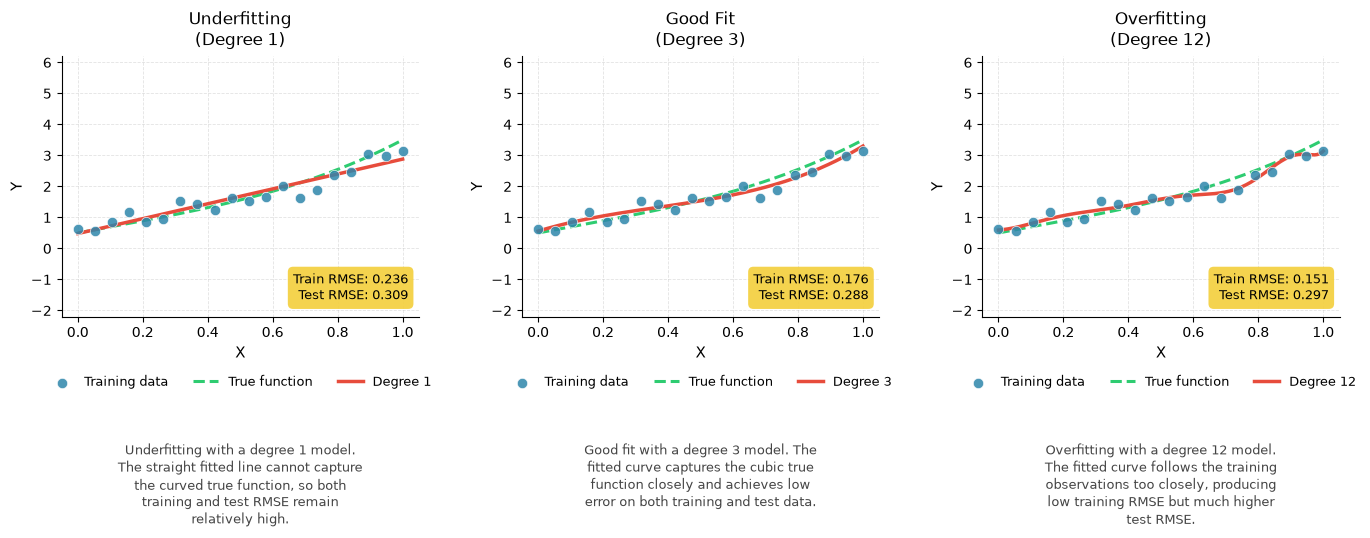

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# True cubic function
def true_function(x):
    return 1.5 * x**3 - 0.5 * x**2 + 2 * x + 0.5

# Generate training data
n_train = 20
X_train = np.linspace(0, 1, n_train)
y_train = true_function(X_train) + np.random.normal(0, 0.25, n_train)

# Generate test data (denser for evaluation)
X_test = np.linspace(0, 1, 100)
y_test = true_function(X_test) + np.random.normal(0, 0.25, 100)

# Smooth grid for plotting curves
X_plot = np.linspace(0, 1, 300).reshape(-1, 1)

degrees = [1, 3, 12]
titles = [
    "Underfitting\n(Degree 1)",
    "Good Fit\n(Degree 3)",
    "Overfitting\n(Degree 12)"
]
model_labels = ["Degree 1", "Degree 3", "Degree 12"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))

for ax, degree, title, label in zip(axes, degrees, titles, model_labels):
    # Create and fit polynomial model
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    model.fit(X_train.reshape(-1, 1), y_train)
    
    # Predictions
    y_plot = model.predict(X_plot)
    y_train_pred = model.predict(X_train.reshape(-1, 1))
    y_test_pred = model.predict(X_test.reshape(-1, 1))
    
    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Plot
    ax.scatter(X_train, y_train, color='#2E86AB', s=55, alpha=0.85, 
               label='Training data', zorder=3, edgecolors='white', linewidth=0.5)
    ax.plot(X_plot, true_function(X_plot.ravel()), color='#2ECC71', 
            linestyle='--', linewidth=2.2, label='True function', zorder=1)
    ax.plot(X_plot, y_plot, color='#E74C3C', linewidth=2.5, 
            label=label, zorder=2)
    
    # Metrics box
    textstr = f'Train RMSE: {train_rmse:.3f}\nTest RMSE: {test_rmse:.3f}'
    props = dict(boxstyle='round,pad=0.4', facecolor='#F4D03F', 
                 edgecolor='none', alpha=0.92)
    ax.text(0.97, 0.05, textstr, transform=ax.transAxes, fontsize=9.5,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    ax.set_title(title, fontsize=12.5, fontweight='medium', pad=8)
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('Y', fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-2.2, 6.2)
    ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.6)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.32), 
              ncol=3, frameon=False, fontsize=9)
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Descriptions
descriptions = [
    "Underfitting with a degree 1 model.\nThe straight fitted line cannot capture\nthe curved true function, so both\ntraining and test RMSE remain\nrelatively high.",
    "Good fit with a degree 3 model. The\nfitted curve captures the cubic true\nfunction closely and achieves low\nerror on both training and test data.",
    "Overfitting with a degree 12 model.\nThe fitted curve follows the training\nobservations too closely, producing\nlow training RMSE but much higher\ntest RMSE."
]

plt.tight_layout()
plt.subplots_adjust(bottom=0.38)

for ax, desc in zip(axes, descriptions):
    ax.text(0.5, -0.48, desc, transform=ax.transAxes, fontsize=9.2,
            ha='center', va='top', linespacing=1.35,
            color='#444444')
plt.savefig("Plots/OverAndUnderfitting.png", dpi=150)
plt.show()

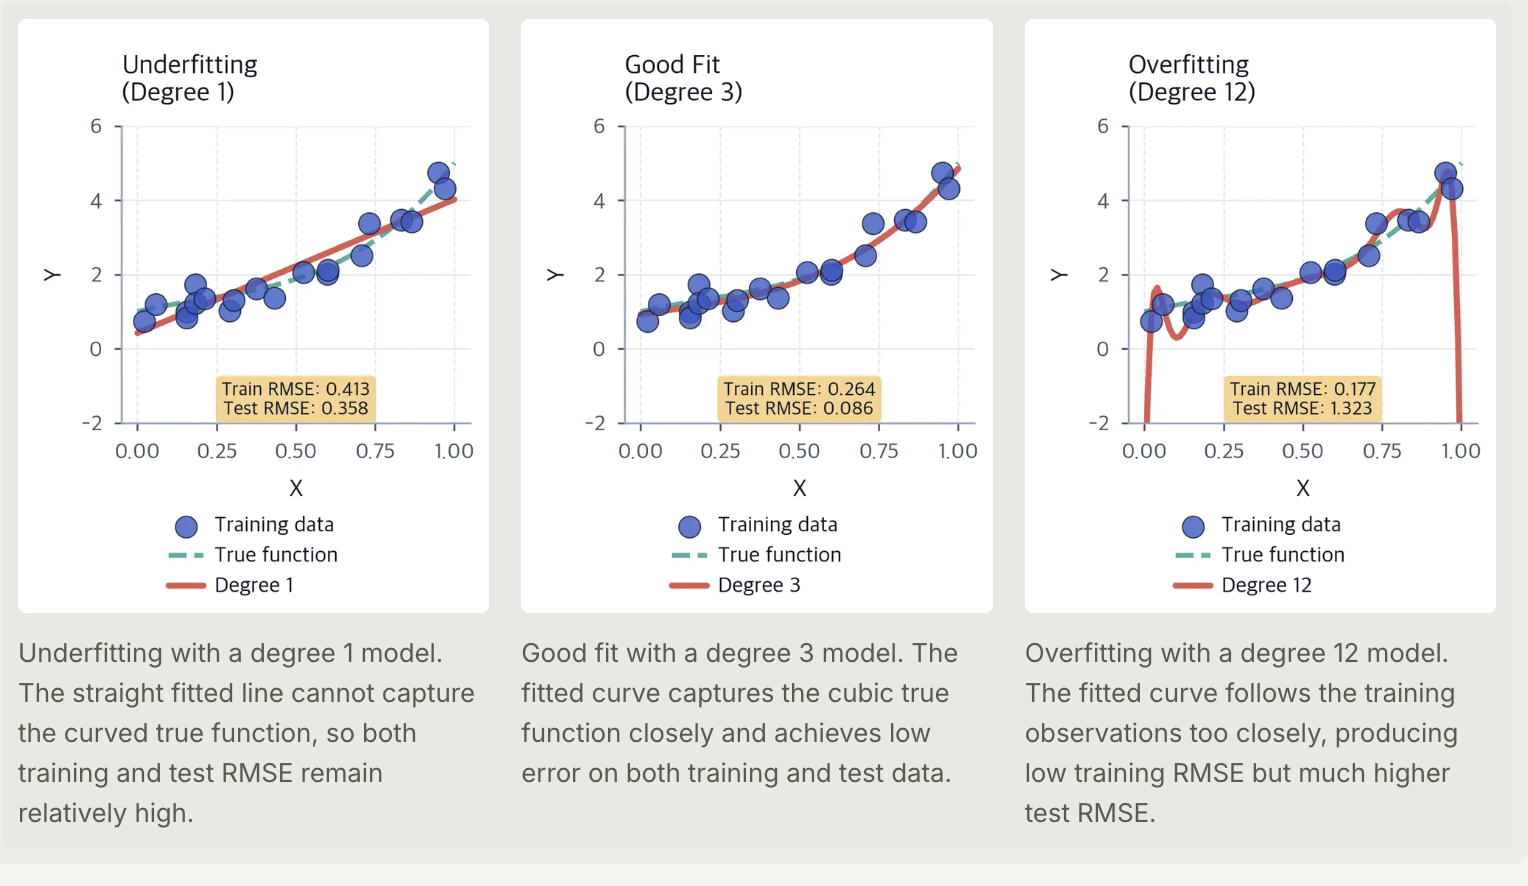

## 6. Cross Validation-Evaluating Models on Held-Out Data

Simply splitting data into training and test sets provides a basic evaluation framework, but this approach has limitations. The performance estimate depends heavily on which specific observations end up in each set, leading to high variance in our assessment. Cross-validation addresses this problem by systematically using different portions of the data for training and testing, producing more stable and reliable performance estimates.


### K-Fold Cross Validation

The most common cross-validation approach is k-fold cross-validation, which divides the dataset into k equally sized folds. The algorithm then trains k different models, each time using k-1 folds for training and the remaining fold for validation. By averaging performance across all k trials, we obtain a robust estimate that reduces the influence of any particular train-test split.

Typical choices for k range from 5 to 10, with k=5 or k=10 being most common. Larger values of k provide more training data for each model and evaluate more splits, but increase computational cost. The extreme case, leave-one-out cross-validation where k equals the number of observations, provides maximum data efficiency but can be prohibitively expensive for large datasets.

### The Cross-Validation Process

The process begins by randomly shuffling the data and partitioning it into k folds. In the first iteration, we train our model on folds 2 through k and evaluate it on fold 1. In the second iteration, we train on folds 1 and 3 through k while evaluating on fold 2. This continues until each fold has served as the validation set exactly once. The final performance metric averages the results across all k iterations, often reported with a standard error to capture variability.

This systematic rotation through the data ensures that every observation is used for both training and validation, maximizing the information we extract from limited data. It also provides insight into model stability. If performance varies dramatically across folds, this suggests the model is sensitive to the specific training examples it sees, which may indicate overfitting or insufficient training data.

### Stratified Cross-Validation

For classification problems, particularly those with imbalanced classes, stratified cross-validation offers an important refinement. Standard k-fold cross-validation might by chance create folds where rare classes are underrepresented or missing entirely. Stratified cross-validation ensures that each fold maintains approximately the same class distribution as the complete dataset, leading to more representative performance estimates and preventing situations where the validation set contains no examples of certain classes.


### Cross Validation for Model Selection

Beyond evaluating a single model's performance, cross-validation helps with comparing different models and selecting hyperparameters. When we need to choose between different model architectures or tune parameters like regularization strength, cross-validation gives an honest assessment of how each configuration will perform on new data. The key is to avoid using the test set for these decisions. Instead, we use cross-validation on the training data to select the best model, then evaluate that final model on a held-out test set that has never been seen during the model development process.


**Example: Visualizing Cross-Validation Splits**

This example illustrates how 5-fold cross-validation systematically rotates through the data, with each fold serving as validation data once while the remaining folds provide training data.

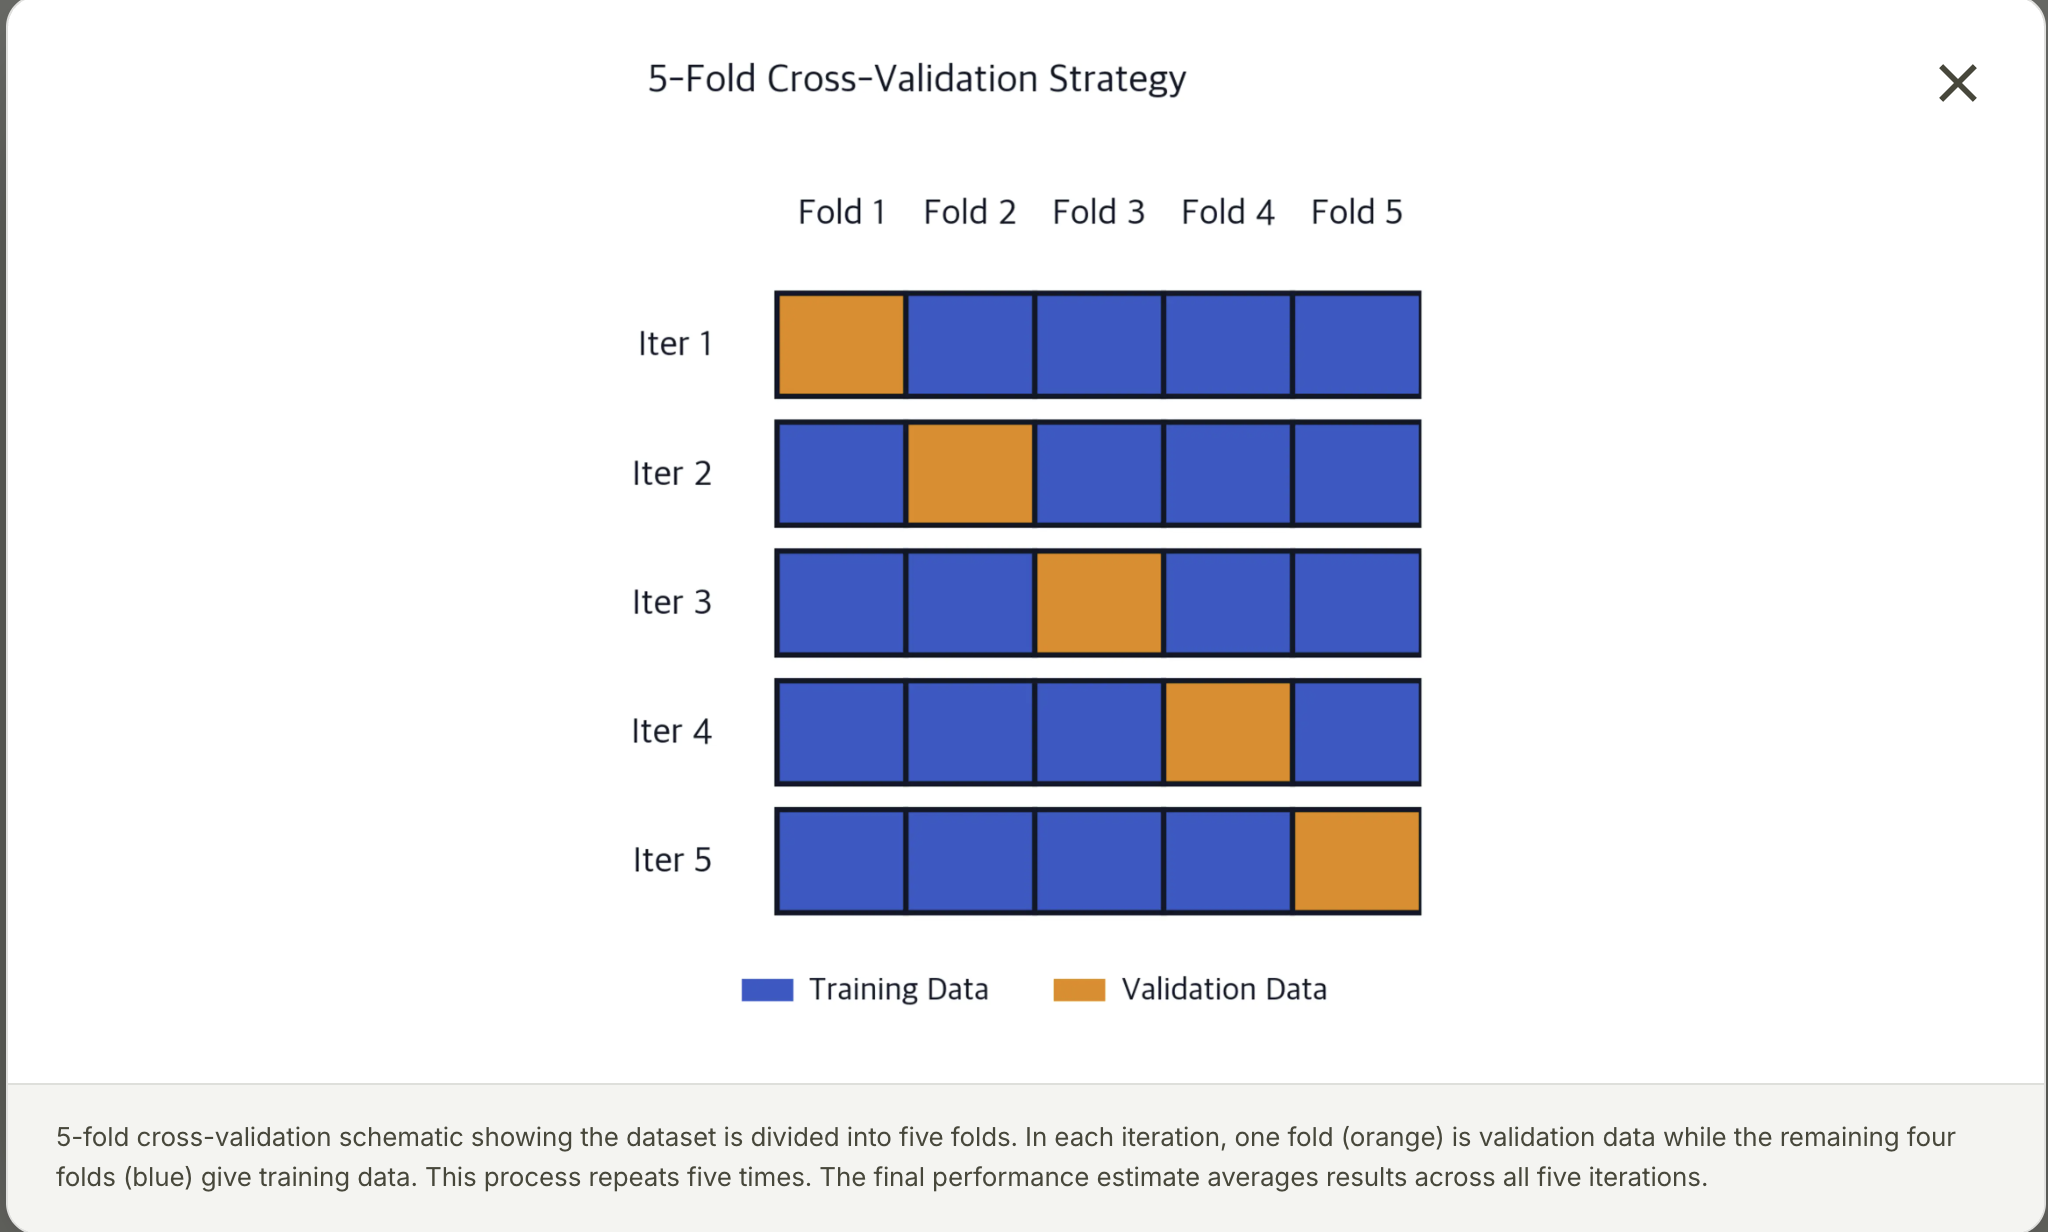

## 7. Practical Applications

Statistical modeling concepts apply across virtually every data science domain. In predictive analytics for business, companies use these principles to build models that forecast sales, predict customer churn, or estimate credit risk. The metrics discussed here help quantify prediction accuracy in dollars or percentage points, making it possible to calculate the business value of improved models. Cross-validation ensures these models perform reliably when deployed on new customers or time periods.

In healthcare, models predict patient outcomes, disease progression, or treatment efficacy. Here the stakes are particularly high. Overfitting could lead to models that perform well in clinical trials but fail in broader populations. Rigorous cross-validation helps identify this problem before deployment, while metrics like RMSE provide interpretable measures of prediction error in clinically meaningful units like days of hospital stay or probability of readmission.

Scientific research employs these techniques to understand relationships between variables and make predictions about natural phenomena. Climate scientists build models to predict temperature changes or extreme weather events, using cross-validation to ensure predictions hold across different time periods and geographic regions. Ecologists model species populations, where understanding the difference between model uncertainty and natural variability is important for conservation decisions.

In engineering applications, models predict system failures, optimize manufacturing processes, or control autonomous systems. The bias-variance tradeoff becomes particularly important in robotics, where underfit models may fail to move through complex environments while overfit models might not transfer from simulation to reality. Cross-validation helps tune these models to achieve reliable real-world performance.

## 8. Limitations and Considerations

While the metrics and techniques discussed provide powerful tools for model evaluation, they come with important caveats that practitioners should understand. R-squared and RMSE only measure prediction accuracy on the specific data we have. They say nothing about whether our model will work on fundamentally different populations or whether it has captured causal relationships that remain stable under interventions. A model with excellent metrics might still fail catastrophically if deployed in a context that differs from the training environment.

Cross-validation assumes that the data points are independent and identically distributed. This assumption breaks down in many real-world scenarios. Time series data exhibits temporal dependencies that violate independence, requiring specialized cross-validation strategies that respect temporal order. Hierarchical or clustered data where observations within groups are correlated requires cluster-aware cross-validation to avoid overoptimistic performance estimates.

The choice of evaluation metric matters enormously and should align with the costs and benefits in the application domain. RMSE weights all errors equally after squaring, but in many applications, different types of errors have vastly different consequences. Predicting that a disease is absent when it is present might be far more costly than the reverse error. In such cases, specialized metrics or cost-sensitive evaluation frameworks provide more appropriate assessments.

Cross-validation provides honest performance estimates but doesn't eliminate the fundamental challenge of limited data. If we have only a small dataset, even carefully cross-validated performance estimates will have high uncertainty. No amount of clever evaluation can substitute for collecting more data when the training set is too small to support the complexity of the model we're trying to build.

Finally, all these techniques assume we've properly prepared our data and chosen appropriate model architectures. No evaluation framework can rescue a model built on the wrong features, with serious data quality issues, or using an architecture fundamentally unsuited to the problem. These tools help us evaluate and compare models, but they don't replace the need for domain knowledge, careful feature engineering, and thoughtful model design.

## Summary

Statistical modeling requires careful attention to three interconnected concepts that together determine whether our models will succeed in practice. First, we should quantify model fit using appropriate metrics that capture prediction accuracy in meaningful ways. R-squared provides an intuitive proportional measure of variance explained, while RMSE offers an absolute error metric in the original units of the target variable. These metrics give us concrete numbers to compare models and track improvement, but they should be interpreted carefully in context.

Second, we need to manage the fundamental tradeoff between underfitting and overfitting by finding the right level of model complexity. Underfit models are too simple to capture real patterns and perform poorly on both training and test data. Overfit models are so complex they memorize noise rather than learning generalizable relationships, achieving excellent training performance but failing on new data. The goal is to find the sweet spot where the model captures true patterns without learning spurious noise, balancing bias against variance.

Finally, cross-validation provides the methodological rigor necessary to evaluate model performance and make sound decisions about model selection and hyperparameters. By systematically rotating through different train-validation splits, cross-validation produces stable performance estimates that are less dependent on any particular division of the data. This approach maximizes the information we extract from limited data while protecting against overfitting to a single test set.

Together, these concepts form the basis of principled model development. They apply whether we're fitting simple linear regressions or training complex deep learning systems. Mastering these fundamentals allows data scientists to move beyond simply fitting models to systematically developing solutions that perform well in production environments.